In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=1000,n_features=2,noise=0.3,n_targets=1)

In [7]:
x

array([[ 1.94213674,  1.66572148],
       [ 0.214758  ,  0.80139154],
       [-0.52760664,  0.06865276],
       ...,
       [ 0.67585089,  2.13466198],
       [ 0.17751766, -0.33033185],
       [-0.71638492, -0.34971974]])

In [8]:
y

array([ 3.49151445e+02,  9.61348754e+01, -4.69277437e+01, -1.60995800e+02,
       -1.27932635e+02, -1.96106013e+02, -8.95134633e+00,  2.11492799e+02,
        2.43065504e+02, -2.09249890e+01,  6.16800845e+01,  1.36291855e+01,
       -2.11972623e+02,  2.28238617e+02, -4.05434715e+01, -1.75917994e+02,
       -3.91390649e+01, -7.93527136e+01,  1.14518475e+02, -1.69264015e+01,
       -3.85890615e+01,  1.57979540e+02,  8.78856907e+00, -1.20595017e+02,
       -2.40449595e+02, -1.76236580e+02, -1.12646838e+02,  4.54233833e+01,
       -3.74190859e+00, -3.06759086e+01, -1.10131898e+02,  1.47642197e+02,
       -1.08662944e+02, -6.37869500e+01,  9.25289359e+01,  1.84904110e+02,
        6.07885288e+01, -1.49566009e+02, -1.21564470e+01, -8.08233461e+01,
       -1.08203018e+02,  6.65698390e+00, -2.85331943e+02, -7.19139344e+01,
       -4.05165069e+01, -1.27836173e+02, -1.41980030e+02,  1.74189957e+02,
        3.23484301e+01,  6.93448346e+01,  1.97457359e+02, -1.98842706e+01,
        2.08894620e+02, -

In [9]:
df=pd.DataFrame(x)

In [10]:
df['target']=y

<Axes: xlabel='0', ylabel='1'>

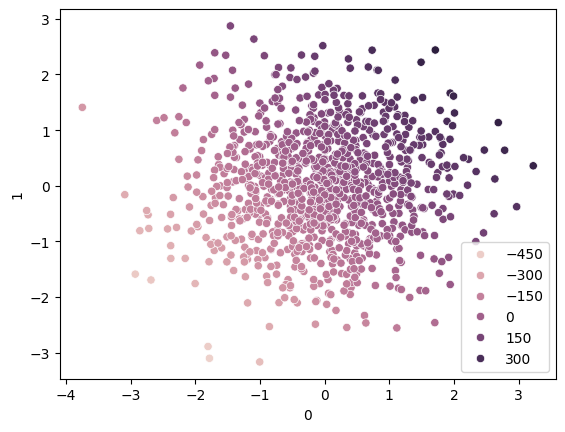

In [12]:
sns.scatterplot(x=df[0],y=df[1],hue=y)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

In [14]:
from sklearn.svm import SVR
svr = SVR(kernel = 'linear')

In [16]:
svr.fit(X_train,y_train)

,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [17]:
y_pred=svr.predict(X_test)

In [18]:
from sklearn.metrics import *

In [19]:
r2_score(y_test,y_pred)

0.9999940873127999

In [20]:
from sklearn.model_selection import GridSearchCV
params = {'C': [0.1, 0.2, 1, 2, 3, 10, 50, 100],
         'gamma': [1, 0.1, 0.2, 0.001, 0.003],
         'kernel': ['linear'],
         'epsilon': [0.01, 0.1, 0.2, 0.3]}


grid = GridSearchCV(SVR(), param_grid=params, cv = 5, verbose = 3)

In [21]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
[CV 1/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.538 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.541 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.543 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.554 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=1, kernel=linear;, score=0.528 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.538 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.541 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.543 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.554 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.01, gamma=0.1, kernel=linear;, score=0.528 total time=   0.0s
[CV 1/5] END C=0.1, epsilon

,estimator,SVR()
,param_grid,"{'C': [0.1, 0.2, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['linear']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


In [22]:
grid.best_params_

{'C': 100, 'epsilon': 0.3, 'gamma': 1, 'kernel': 'linear'}